In [56]:
import torch
import torchvision
from torch import nn
from torch.utils.data import DataLoader,Subset
from torchvision import datasets,transforms
import matplotlib.pyplot as plt
from torchinfo import summary
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np


from pathlib import Path

In [36]:
if torch.mps.is_available():
    device = "mps"
elif torch.cuda.is_available():
    device = "cuda"
else:
    device = "cpu"
device

'cuda'

In [37]:
train_path = Path("Training")
test_path = Path("Testing")

In [38]:
def mean_std(train_data):
    # Normalizasyonsuz dataloader oluştur
    loader = DataLoader(train_data, batch_size=1000, shuffle=False)

    mean = torch.zeros(3)
    std = torch.zeros(3)

    for X, _ in loader:
        # X shape: [batch, 3, H, W]
        mean += X.mean(dim=[0, 2, 3])  # her kanal için ortalama
        std += X.std(dim=[0, 2, 3])

    mean /= len(loader)
    std /= len(loader)

    return mean, std

In [39]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

train_data = datasets.ImageFolder(root=train_path, transform=transform)
test_data = datasets.ImageFolder(root=test_path, transform=transform)

In [40]:
mean, std = mean_std(train_data)

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),        # önce biraz büyük resize
    transforms.RandomResizedCrop(224),    # sonra 224'e random crop
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])


train_data = datasets.ImageFolder(root=train_path, transform=train_transform)
test_data = datasets.ImageFolder(root=test_path, transform=test_transform)

In [41]:
class_names = train_data.classes

In [42]:
class_names

['glioma', 'meningioma', 'notumor', 'pituitary']

In [43]:
BATCH_SIZE=32

train_dataloader = DataLoader(
    dataset=train_data,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test_dataloader = DataLoader(
    dataset=test_data,
    batch_size=BATCH_SIZE,
    shuffle=False
)

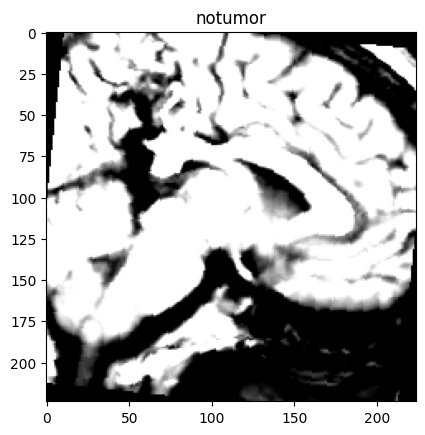

In [44]:
img, label = train_data[4000]
plt.imshow(img.permute(1, 2, 0))
plt.title(train_data.classes[label])
plt.show()

In [45]:
class BrainTumorCNN(nn.Module):
    def __init__(self, input_shape, output_shape):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=32, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(32),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )

        self.block2 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(2),
            nn.Dropout(0.25)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2),
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(128, 256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 14 * 14, 128),   # Dense Layer
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, output_shape)     # Classification
        )

    def forward(self,x):
        x=self.block1(x)
        x=self.block2(x)
        x=self.block3(x)
        x=self.block4(x)

        return self.classifier(x)

In [46]:
torch.manual_seed(42)
model = BrainTumorCNN(
    input_shape=3,
    output_shape=4).to(device)

In [ ]:
summary(
    model=model,
    input_size=[1,3,224,224],
    col_names=(
                "input_size",
                "output_size",
                "trainable")
)

Layer (type:depth-idx)                   Input Shape               Output Shape              Trainable
BrainTumorCNN                            [1, 3, 224, 224]          [1, 4]                    True
├─Sequential: 1-1                        [1, 3, 224, 224]          [1, 32, 112, 112]         True
│    └─Conv2d: 2-1                       [1, 3, 224, 224]          [1, 32, 224, 224]         True
│    └─ReLU: 2-2                         [1, 32, 224, 224]         [1, 32, 224, 224]         --
│    └─BatchNorm2d: 2-3                  [1, 32, 224, 224]         [1, 32, 224, 224]         True
│    └─MaxPool2d: 2-4                    [1, 32, 224, 224]         [1, 32, 112, 112]         --
│    └─Dropout: 2-5                      [1, 32, 112, 112]         [1, 32, 112, 112]         --
├─Sequential: 1-2                        [1, 32, 112, 112]         [1, 64, 56, 56]           True
│    └─Conv2d: 2-6                       [1, 32, 112, 112]         [1, 64, 112, 112]         True
│    └─ReLU: 2-7     

In [ ]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,      # 0.1 yerine 0.5 — daha yavaş düşsün
    patience=10,     # 5 yerine 10 — daha sabırlı olsun
    min_lr=1e-5
)

loss_fn = nn.CrossEntropyLoss()

In [ ]:
def calculate_accuracy(y_pred,y_test):
    correct = torch.eq(y_pred,y_test).sum().item()
    accuracy = (correct / len(y_test)) * 100
    return accuracy

In [ ]:
epochs=50
epoch_list =[]
train_acc_list=[]
test_acc_list=[]
test_loss_list=[]
train_loss_list=[]

In [ ]:
torch.manual_seed(42)

for epoch in range(epochs):

    total_train_loss=0
    total_train_acc=0

    model.train()
    for X,y in train_dataloader:
        X,y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred,y)

        total_train_acc += calculate_accuracy(y_pred.argmax(dim=1), y)
        total_train_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    avg_train_loss = total_train_loss / len(train_dataloader)
    avg_train_acc = total_train_acc / len(train_dataloader)


    total_test_loss=0
    total_test_acc=0

    model.eval()
    with torch.inference_mode():
        for X,y in test_dataloader:
            X,y = X.to(device), y.to(device)
            y_test_pred = model(X)
            test_loss = loss_fn(y_test_pred, y)

            total_test_loss += test_loss.item()
            total_test_acc += calculate_accuracy(y_test_pred.argmax(dim=1), y)

        avg_test_loss = total_test_loss / len(test_dataloader)
        avg_test_acc = total_test_acc / len(test_dataloader)


    scheduler.step(avg_test_loss)

    epoch_list.append(epoch+1)
    train_acc_list.append(avg_train_acc)
    test_acc_list.append(avg_test_acc)
    test_loss_list.append(avg_test_loss)
    train_loss_list.append(avg_train_loss)

    print(f"Epoch:{epoch+1}, Train Loss:{avg_train_loss:.3f}, Test Loss:{avg_test_loss:.3f}",
    f"Train Acc:{avg_train_acc:.3f}, Test Acc:{avg_test_acc:.3f}")

Epoch:1, Train Loss:1.769, Test Loss:1.506 Train Acc:40.143, Test Acc:53.688
Epoch:2, Train Loss:1.231, Test Loss:1.183 Train Acc:43.518, Test Acc:47.438
Epoch:3, Train Loss:1.178, Test Loss:1.294 Train Acc:46.518, Test Acc:58.500
Epoch:4, Train Loss:1.154, Test Loss:1.186 Train Acc:47.071, Test Acc:53.125
Epoch:5, Train Loss:1.151, Test Loss:1.242 Train Acc:48.625, Test Acc:56.938
Epoch:6, Train Loss:1.124, Test Loss:1.099 Train Acc:49.625, Test Acc:59.438
Epoch:7, Train Loss:1.101, Test Loss:1.146 Train Acc:50.107, Test Acc:56.688
Epoch:8, Train Loss:1.075, Test Loss:1.363 Train Acc:52.161, Test Acc:67.062
Epoch:9, Train Loss:1.073, Test Loss:0.913 Train Acc:52.893, Test Acc:70.125
Epoch:10, Train Loss:1.049, Test Loss:0.817 Train Acc:52.893, Test Acc:67.250
Epoch:11, Train Loss:1.048, Test Loss:1.120 Train Acc:53.929, Test Acc:72.812
Epoch:12, Train Loss:1.012, Test Loss:1.189 Train Acc:55.607, Test Acc:66.188
Epoch:13, Train Loss:0.985, Test Loss:1.028 Train Acc:56.571, Test Acc:69

In [49]:
#torch.save(model.state_dict(), 'brain_tumor_cnn.pth')

In [51]:
model.load_state_dict(torch.load('brain_tumor_cnn.pth', map_location=device))
model.eval()

BrainTumorCNN(
  (block1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (block3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block4): Sequential(
    

In [60]:
"""
import json
lists = {
    'epoch': epoch_list,
    'train_acc': train_acc_list,
    'test_acc': test_acc_list,
    'train_loss': train_loss_list,
    'test_loss': test_loss_list
}
with open('training_history.json', 'w') as f:
    json.dump(lists, f)

"""

"\nimport json\nlists = {\n    'epoch': epoch_list,\n    'train_acc': train_acc_list,\n    'test_acc': test_acc_list,\n    'train_loss': train_loss_list,\n    'test_loss': test_loss_list\n}\nwith open('training_history.json', 'w') as f:\n    json.dump(lists, f)\n\n"

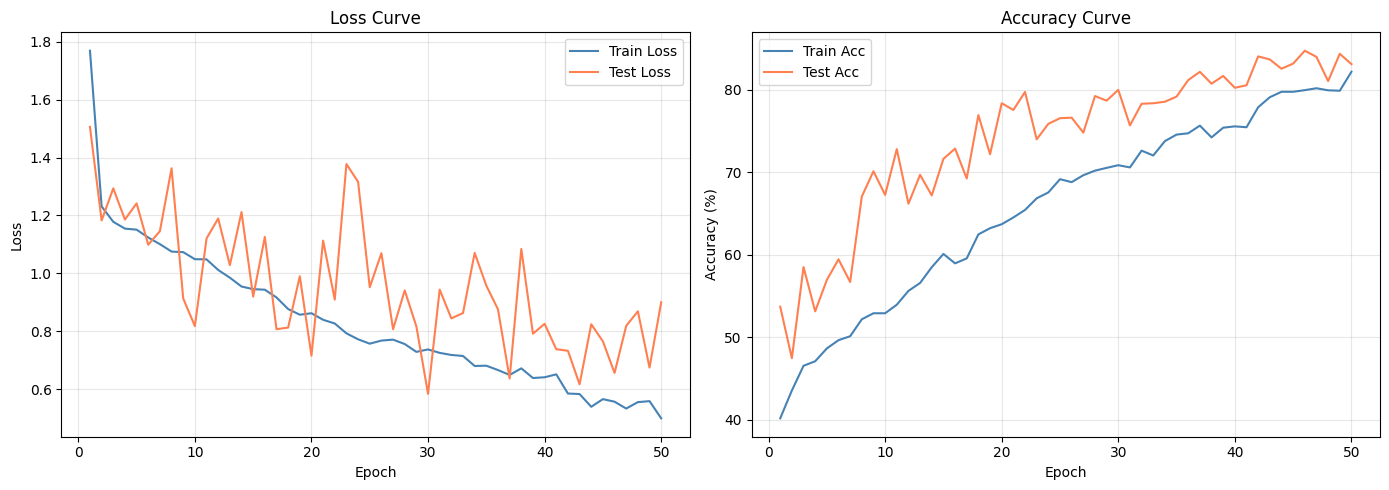

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(epoch_list, train_loss_list, label='Train Loss', color='steelblue')
axes[0].plot(epoch_list, test_loss_list, label='Test Loss', color='coral')
axes[0].set_title('Loss Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epoch_list, train_acc_list, label='Train Acc', color='steelblue')
axes[1].plot(epoch_list, test_acc_list, label='Test Acc', color='coral')
axes[1].set_title('Accuracy Curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

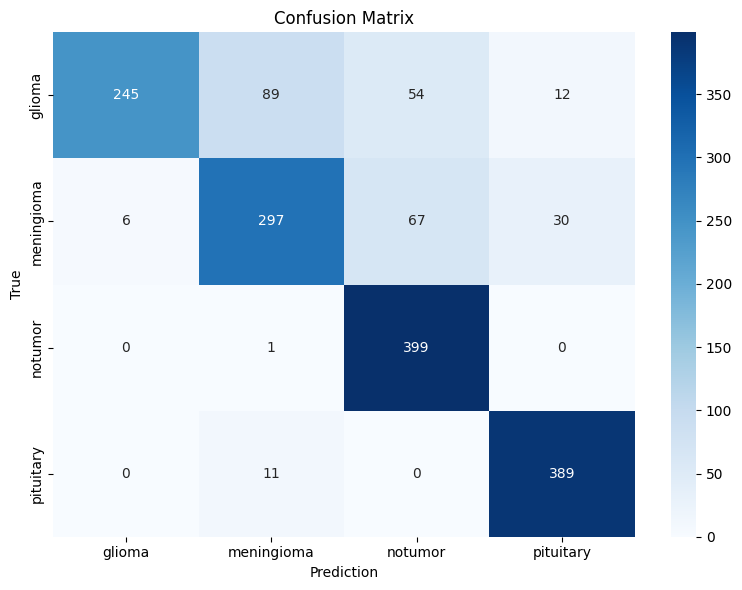

              precision    recall  f1-score   support

      glioma       0.98      0.61      0.75       400
  meningioma       0.75      0.74      0.74       400
     notumor       0.77      1.00      0.87       400
   pituitary       0.90      0.97      0.94       400

    accuracy                           0.83      1600
   macro avg       0.85      0.83      0.83      1600
weighted avg       0.85      0.83      0.83      1600



In [55]:
all_preds = []
all_labels = []

model.eval()
with torch.inference_mode():
    for X, y in test_dataloader:
        X, y = X.to(device), y.to(device)
        preds = model(X).argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.ylabel('True')
plt.xlabel('Prediction')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(classification_report(all_labels, all_preds, target_names=class_names))

In [57]:
def grad_cam(model, img_tensor, class_idx, target_layer):
    model.eval()
    activations = []
    gradients = []

    def forward_hook(module, input, output):
        activations.append(output)

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    fh = target_layer.register_forward_hook(forward_hook)
    bh = target_layer.register_full_backward_hook(backward_hook)

    output = model(img_tensor)
    model.zero_grad()
    output[0, class_idx].backward()

    fh.remove()
    bh.remove()

    act = activations[0].squeeze(0)      # [256, 14, 14]
    grad = gradients[0].squeeze(0)       # [256, 14, 14]

    weights = grad.mean(dim=[1, 2])      # [256]
    cam = (weights[:, None, None] * act).sum(dim=0)  # [14, 14]
    cam = torch.relu(cam)
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)

    return cam.detach().cpu().numpy()

In [58]:
import numpy as np
import cv2

def show_gradcam_grid(model, dataset, class_names, target_layer, n_per_class=2):
    fig, axes = plt.subplots(len(class_names), n_per_class * 2, figsize=(14, 14))

    # her sınıftan n_per_class örnek topla
    class_samples = {i: [] for i in range(len(class_names))}
    for img, label in dataset:
        if len(class_samples[label]) < n_per_class:
            class_samples[label].append((img, label))
        if all(len(v) == n_per_class for v in class_samples.values()):
            break

    for row, cls_idx in enumerate(range(len(class_names))):
        for col, (img, label) in enumerate(class_samples[cls_idx]):
            img_tensor = img.unsqueeze(0).to(device)

            with torch.no_grad():
                pred = model(img_tensor).argmax(dim=1).item()

            cam = grad_cam(model, img_tensor, pred, target_layer)

            # görüntüyü denormalize et
            img_np = img.permute(1, 2, 0).numpy()
            img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min())
            img_np = (img_np * 255).astype(np.uint8)

            # cam'i görüntü boyutuna getir
            cam_resized = cv2.resize(cam, (224, 224))
            heatmap = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
            overlay = cv2.addWeighted(img_np, 0.5, heatmap, 0.5, 0)

            # orijinal görüntü
            ax_orig = axes[row, col * 2]
            ax_orig.imshow(img_np)
            ax_orig.set_title(f'Gerçek: {class_names[label]}\nTahmin: {class_names[pred]}',
                             fontsize=9,
                             color='green' if pred == label else 'red')
            ax_orig.axis('off')

            # grad-cam overlay
            ax_cam = axes[row, col * 2 + 1]
            ax_cam.imshow(overlay)
            ax_cam.set_title('Grad-CAM', fontsize=9)
            ax_cam.axis('off')

    plt.suptitle('Grad-CAM Analizi — Her Sınıftan 2 Örnek', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.savefig('gradcam_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

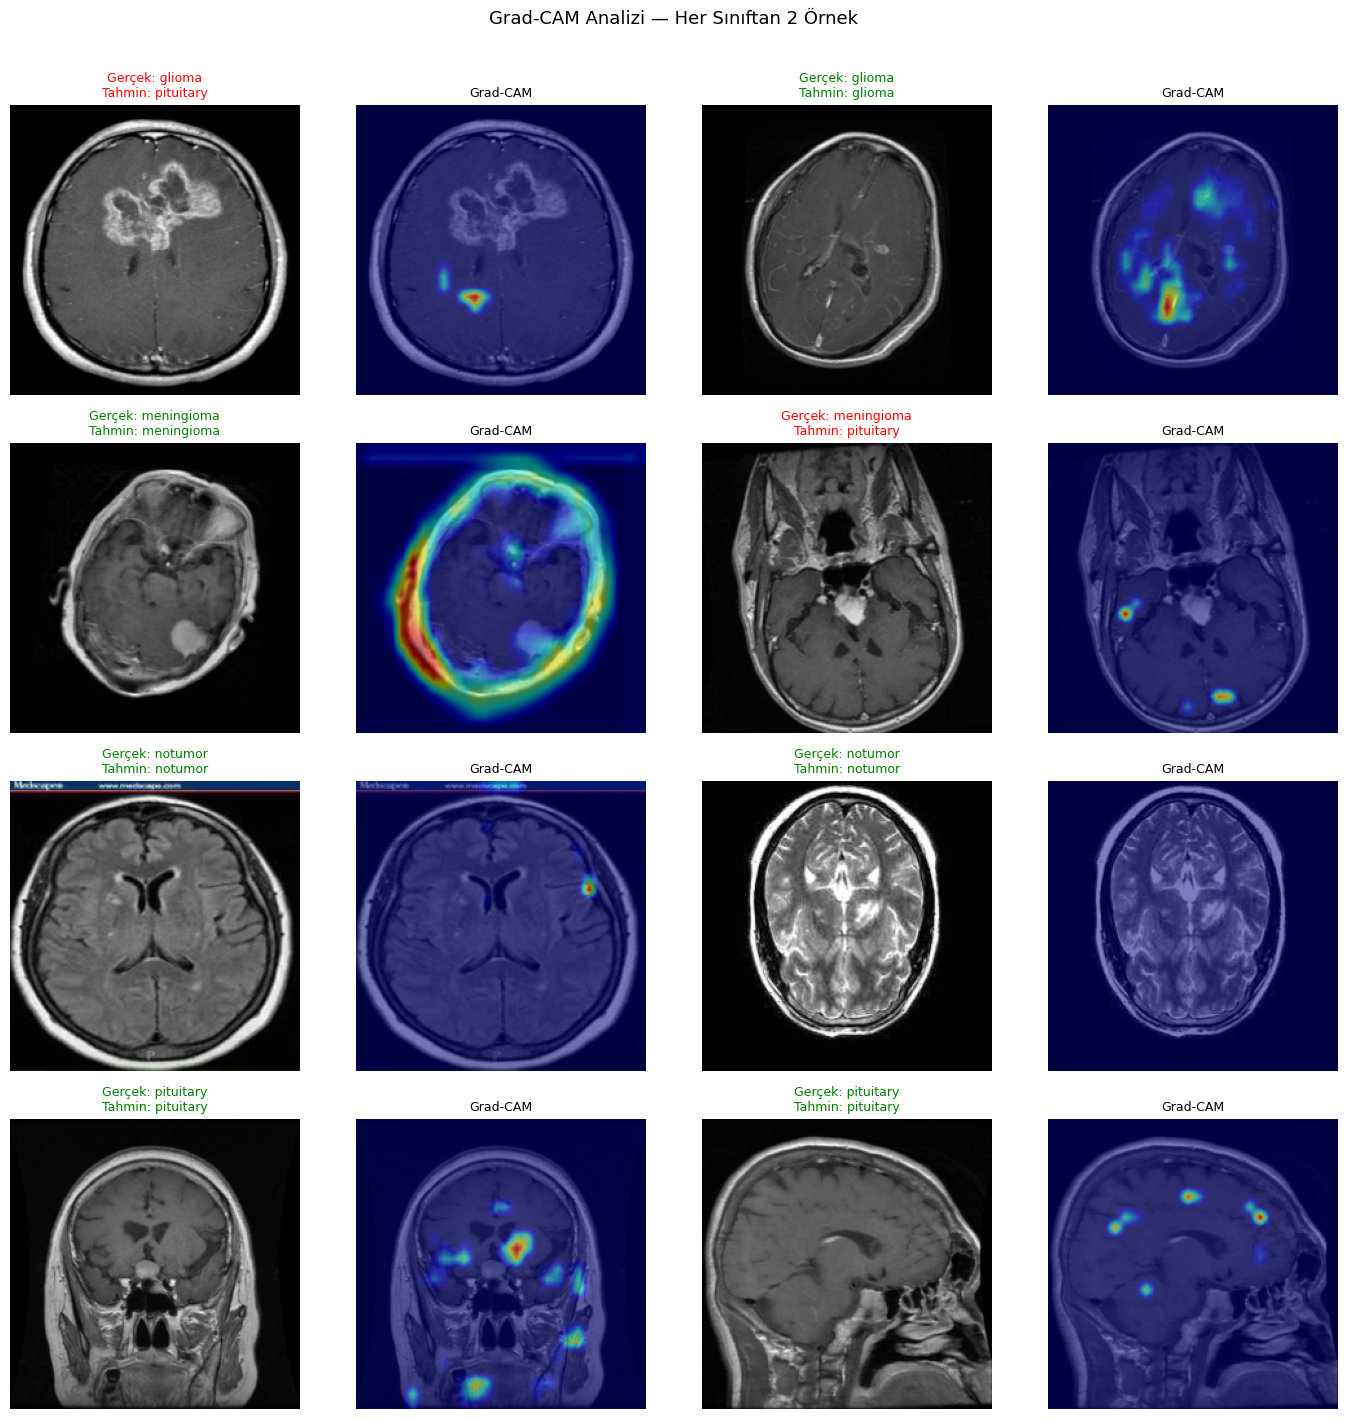

In [59]:
# block4'ün son Conv2d katmanını hedef al
target_layer = model.block4[0]  # Conv2d(128→256)

show_gradcam_grid(model, test_data, class_names, target_layer, n_per_class=2)